## Ejercicio 3: Inspección visual de un producto

#### *Ficha PEAS*

| PEAS | Descripción |
| :--- | :--- |
| **Percepción (S)** | Matriz 5×5 de NumPy capturada por la cámara, donde cada valor es 0 (píxel normal) o 1 (píxel defectuoso) |
| **Acciones (A)** | Aprobar el producto, enviarlo a revisión manual, rechazarlo |
| **Entorno (E)** | La línea de producción, con productos pasando continuamente frente a la cámara. |
| **Objetivo** | Detectar productos defectuosos antes de que lleguen al cliente, sin descartar productos en buen estado. |
| **Medida de desempeño (P)** | Proporción de defectos detectados correctamente, minimizando tanto productos defectuosos aprobados por error como productos buenos rechazados innecesariamente.|

## *justificacion de las reglas*

Un solo píxel defectuoso aislado no afecta la funcionalidad del producto, por lo que no amerita rechazo directo, pero tampoco debe aprobarse sin más. De ahí que 1 a 3 defectos pasen a revisión manual, donde una persona confirma si es un defecto real o un falso positivo del sensor. Cuando los defectos superan a 3, la probabilidad de que sea un defectuoso es alta, se rechaza para no saturar la revisión manual con productos claramente malos.

### *Codigo*

-**La variable defectos comprara cada valor de matriz y da si es verdadero o falso segun sea 1 o 0.**
-**np.sum(..) cuenta cuantos verdaderos hay.**
se utiliza la imagen prueba 

In [1]:
import numpy as np

def agente_inspeccion(imagen):
    """
    Percepcion (S): matriz 5x5 de NumPy (0 = normal, 1 = defectuoso)
    """
    defectos = np.sum(imagen == 1)
    if defectos == 0:
        return "aprobar", "no se detectaron pixeles defectuosos"
    elif defectos <= 3:
        return "revision manual", f"se detectaron {defectos} pixeles defectuosos"
    else:
        return "rechazar", f"se detectaron {defectos} pixeles defectuosos"

imagen_prueba = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
])
print(agente_inspeccion(imagen_prueba))

('revision manual', 'se detectaron 3 pixeles defectuosos')


## *Simulación con mínimo 4 matrices, incluyendo 0 defectos y un caso límite*

In [7]:
imagen_sin_defectos = np.zeros((5, 5), dtype=int) # Representa una imagen sin ningún defecto, donde 0 significa "sin defecto".

imagen_un_defecto = np.zeros((5, 5), dtype=int)
imagen_un_defecto[2, 2] = 1

imagen_caso_limite = np.zeros((5, 5), dtype=int)
imagen_caso_limite[0, 0] = 1
imagen_caso_limite[1, 1] = 1
imagen_caso_limite[2, 2] = 1
imagen_caso_limite[3, 3] = 1  # exactamente 4 -> justo pasa el umbral de "revision manual"

imagen_muchos_defectos = np.ones((5, 5), dtype=int)

pruebas = [imagen_sin_defectos, imagen_un_defecto, imagen_caso_limite, imagen_muchos_defectos]

for img in pruebas: # El for recorre la lista con imagenes etiquetadas 
    print(agente_inspeccion(img))

('aprobar', 'no se detectaron pixeles defectuosos')
('revision manual', 'se detectaron 1 pixeles defectuosos')
('rechazar', 'se detectaron 4 pixeles defectuosos')
('rechazar', 'se detectaron 25 pixeles defectuosos')


## *visualizar cada imagen*

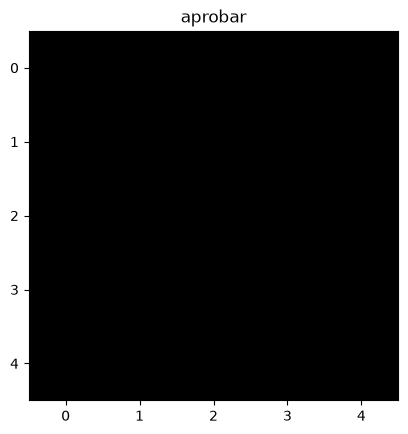

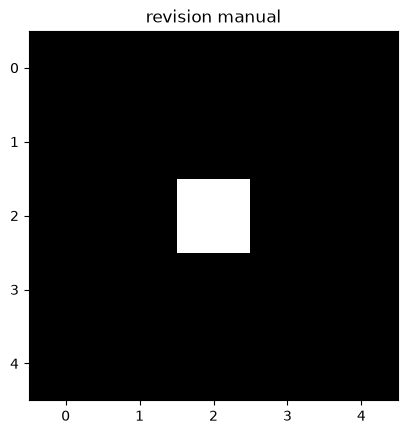

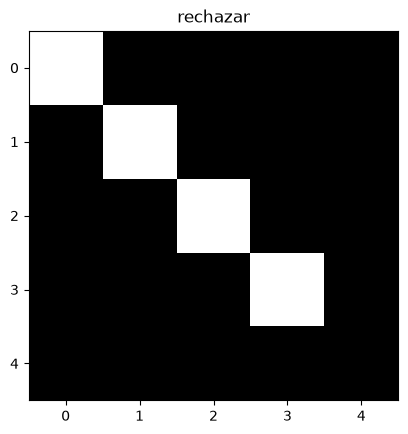

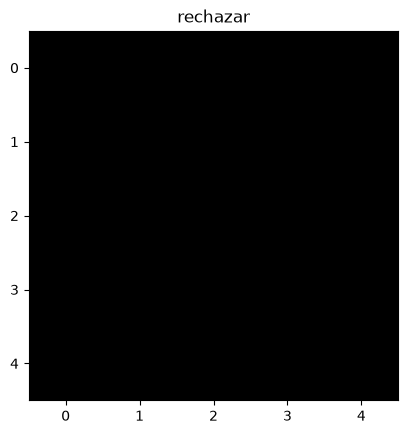

In [4]:
import matplotlib.pyplot as plt

for img in pruebas:
    plt.imshow(img, cmap="gray")
    plt.title(agente_inspeccion(img)[0])
    plt.show()